# **Data Security Mini Project**

This notebook implements a malicious URL detection system using Logistic Regression and LSTM models. It includes data preprocessing, feature extraction, model training with hyperparameter tuning, evaluation, and visualizations to enrich the project report.

**Authors**: Abdelillah Serghine, Dait Dehane Yacine, **Group**: G:02 IASD

## **1. Loading Data**

In [1]:
# Define the path to the dataset
path = "./malicious_phish.csv"

## **2. Importing Libraries**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from urllib.parse import urlparse
from tld import get_tld
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import pickle

%matplotlib inline

## **3. Exploratory Data Analysis**

Dataset Shape: (651191, 2)

First 5 Rows:
                                                 url        type
0                                   br-icloud.com.br    phishing
1                mp3raid.com/music/krizz_kaliko.html      benign
2                    bopsecrets.org/rexroth/cr/1.htm      benign
3  http://www.garage-pirenne.be/index.php?option=...  defacement
4  http://adventure-nicaragua.net/index.php?optio...  defacement

Column Names:
Index(['url', 'type'], dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 651191 entries, 0 to 651190
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   url     651191 non-null  object
 1   type    651191 non-null  object
dtypes: object(2)
memory usage: 9.9+ MB

There are 2 categorical variables: ['url', 'type']

Missing Values:
url     0
type    0
dtype: int64

Cardinality of Categorical Variables:
url contains 641119 labels
type contains 4 labels


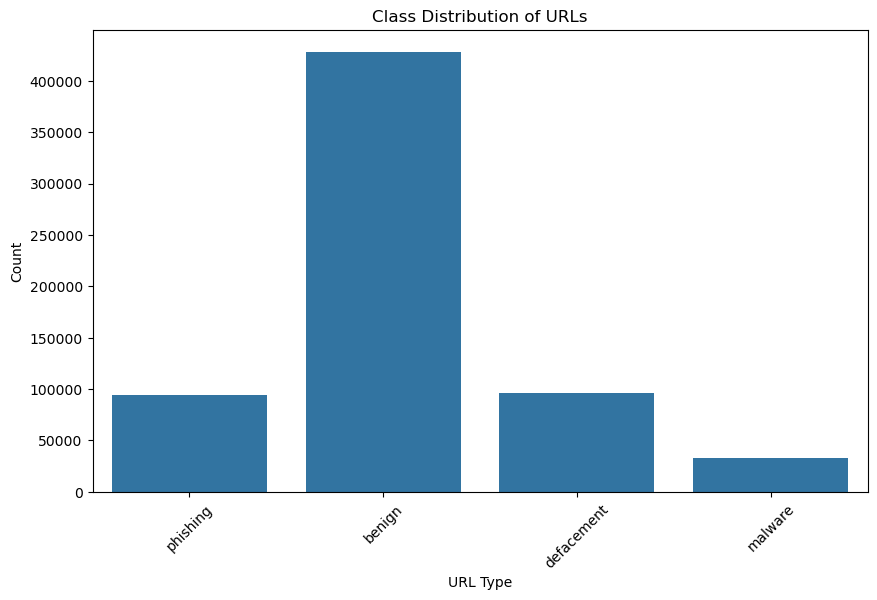

In [3]:
# Load the dataset
df = pd.read_csv(path)

# Display basic information
print(f"Dataset Shape: {df.shape}")
print("\nFirst 5 Rows:")
print(df.head())
print("\nColumn Names:")
print(df.columns)
print("\nDataset Info:")
df.info()

# Check for categorical variables
categorical = [var for var in df.columns if df[var].dtype == 'O']
print(f"\nThere are {len(categorical)} categorical variables: {categorical}")

# Check for missing values
print("\nMissing Values:")
print(df[categorical].isnull().sum())

# Check cardinality
print("\nCardinality of Categorical Variables:")
for var in categorical:
    print(f"{var} contains {len(df[var].unique())} labels")

# Plot class distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='type', data=df)
plt.title('Class Distribution of URLs')
plt.xlabel('URL Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.savefig('class_distribution.png')
plt.show()

## **4. Feature Extraction**

In [4]:
 def having_ip_address(url):
    match = re.search(
        r'(([01]?\d\d?|2[0-4]\d|25[0-5])\.){3}([01]?\d\d?|2[0-4]\d|25[0-5])|'
        r'((0x[0-9a-fA-F]{1,2})\.){3}(0x[0-9a-fA-F]{1,2})|'
        r'(?:[a-fA-F0-9]{1,4}:){7}[a-fA-F0-9]{1,4}', url)
    return 1 if match else 0

def abnormal_url(url):
    hostname = str(urlparse(url).hostname)
    return 1 if hostname and hostname in url else 0

def count_dot(url): return url.count('.')
def count_www(url): return url.count('www')
def count_atrate(url): return url.count('@')
def no_of_dir(url): return urlparse(url).path.count('/')
def no_of_embed(url): return urlparse(url).path.count('//')

def suspicious_words(url):
    return 1 if re.search(r'paypal|login|signin|bank|account|update|free|lucky|service|bonus|ebayisapi|webscr', url, re.IGNORECASE) else 0

def shortening_service(url):
    return 1 if re.search(
        r'bit\.ly|goo\.gl|shorte\.st|go2l\.ink|x\.co|ow\.ly|t\.co|tinyurl|tr\.im|is\.gd|cli\.gs|'
        r'yfrog\.com|migre\.me|ff\.im|tiny\.cc|url4\.eu|twit\.ac|su\.pr|twurl\.nl|snipurl\.com|'
        r'short\.to|BudURL\.com|ping\.fm|post\.ly|Just\.as|bkite\.com|snipr\.com|fic\.kr|loopt\.us|'
        r'doiop\.com|short\.ie|kl\.am|wp\.me|rubyurl\.com|om\.ly|to\.ly|bit\.do|t\.co|lnkd\.in|'
        r'db\.tt|qr\.ae|adf\.ly|bitly\.com|cur\.lv|tinyurl\.com|ity\.im|q\.gs|po\.st|bc\.vc|'
        r'twitthis\.com|u\.to|j\.mp|buzurl\.com|cutt\.us|u\.bb|yourls\.org|x\.co|prettylinkpro\.com|'
        r'scrnch\.me|filoops\.info|vzturl\.com|qr\.net|1url\.com|tweez\.me|v\.gd|link\.zip\.net',
        url) else 0

def count_https(url): return url.count('https')
def count_http(url): return url.count('http')
def count_per(url): return url.count('%')
def count_ques(url): return url.count('?')
def count_hyphen(url): return url.count('-')
def count_equal(url): return url.count('=')
def url_length(url): return len(str(url))
def hostname_length(url): return len(urlparse(url).netloc)

def fd_length(url):
    try:
        return len(urlparse(url).path.split('/')[1])
    except:
        return 0

def tld_length(tld):
    try:
        return len(tld)
    except:
        return -1

def digit_count(url): return sum(c.isdigit() for c in url)
def letter_count(url): return sum(c.isalpha() for c in url)

 
def extract_features(url):
    return [
        having_ip_address(url),
        abnormal_url(url),
        count_dot(url),
        count_www(url),
        count_atrate(url),
        no_of_dir(url),
        no_of_embed(url),
        shortening_service(url),
        count_per(url),
        count_ques(url),
        count_hyphen(url),
        count_equal(url),
        url_length(url),
        count_https(url),
        count_http(url),
        hostname_length(url),
        suspicious_words(url),
        fd_length(url),
        tld_length(get_tld(url, fail_silently=True)),
        digit_count(url),
        letter_count(url)
    ]

#apply feature selection
df['features'] = df['url'].apply(extract_features)
feature_df = pd.DataFrame(df['features'].tolist(), columns=[
    'having_ip', 'abnormal_url', 'count_dot', 'count_www', 'count_atrate', 'no_of_dir',
    'no_of_embed', 'shortening_service', 'count_per', 'count_ques', 'count_hyphen',
    'count_equal', 'url_length', 'count_https', 'count_http', 'hostname_length',
    'suspicious_words', 'fd_length', 'tld_length', 'digit_count', 'letter_count'
])

#convert type to binary 'benign' = 0, 'malicious' = 1
df['label'] = df['type'].apply(lambda x: 0 if x == 'benign' else 1)

#combine features
data = pd.concat([feature_df, df['label']], axis=1)

## **5. Data Preprocessing**

In [5]:
#spli data 
X = data.drop('label', axis=1)
y = data['label']

#standaraize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#split DS into train.test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

#reshape for LSTM
X_train_lstm = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_lstm = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

## **6. Logistic Regression Model**

Best Logistic Regression Parameters: {'C': 10, 'solver': 'lbfgs'}

Logistic Regression Evaluation:
Accuracy: 0.9010
Precision: 0.9149
Recall: 0.7838
F1-Score: 0.8443


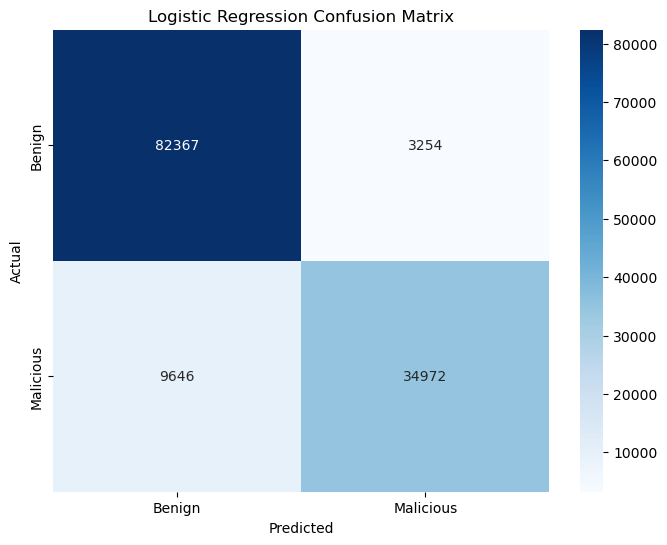

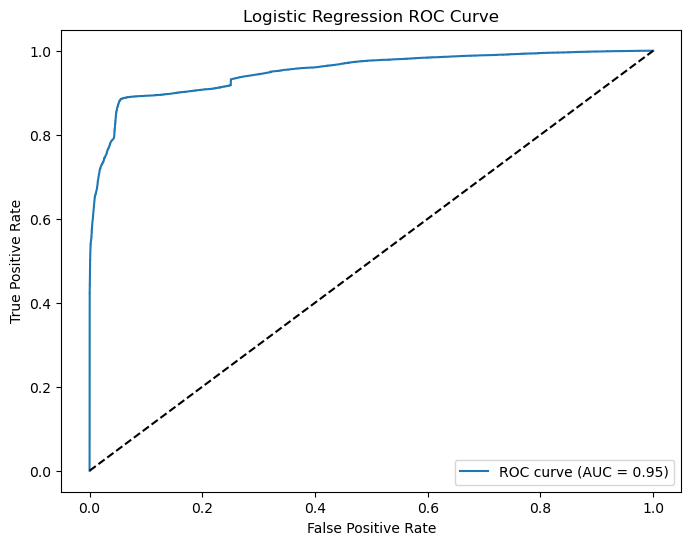

In [6]:
#init LR
lr = LogisticRegression(max_iter=1000)

# HP tuning VIA GirdSearch
param_grid = {'C': [0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']}
grid_search = GridSearchCV(lr, param_grid, cv=5, scoring='f1')
grid_search.fit(X_train, y_train)

# Best model
lr_best = grid_search.best_estimator_
print(f"Best Logistic Regression Parameters: {grid_search.best_params_}")

y_pred_lr = lr_best.predict(X_test)

print("\nLogistic Regression Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lr):.4f}")

#CM
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malicious'], yticklabels=['Benign', 'Malicious'])
plt.title('Logistic Regression Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('lr_confusion_matrix.png')
plt.show()

# ROC Curve
y_pred_prob_lr = lr_best.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_prob_lr)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression ROC Curve')
plt.legend(loc='lower right')
plt.savefig('lr_roc_curve.png')
plt.show()

## **7. LSTM Model**

c:\Users\anaconda3\envs\SEDS_ML\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
3256/3256 ━━━━━━━━━━━━━━━━━━━━ 438s 133ms/step - accuracy: 0.8886 - loss: 0.2894 - val_accuracy: 0.9494 - val_loss: 0.1487
Epoch 2/10
3256/3256 ━━━━━━━━━━━━━━━━━━━━ 419s 129ms/step - accuracy: 0.9485 - loss: 0.1460 - val_accuracy: 0.9585 - val_loss: 0.1199
Epoch 3/10
3256/3256 ━━━━━━━━━━━━━━━━━━━━ 404s 124ms/step - accuracy: 0.9602 - loss: 0.1184 - val_accuracy: 0.9635 - val_loss: 0.1075
Epoch 4/10
3256/3256 ━━━━━━━━━━━━━━━━━━━━ 388s 119ms/step - accuracy: 0.9641 - loss: 0.1077 - val_accuracy: 0.9632 - val_loss: 0.1084
Epoch 5/10
3256/3256 ━━━━━━━━━━━━━━━━━━━━ 384s 118ms/step - accuracy: 0.9665 - loss: 0.1023 - val_accuracy: 0.9667 - val_loss: 0.0990
Epoch 6/10
3256/3256 ━━━━━━━━━━━━━━━━━━━━ 381s 117ms/step - accuracy: 0.9685 - loss: 0.0957 - val_accuracy: 0.9680 - val_loss: 0.0958
Epoch 7/10
3256/3256 ━━━━━━━━━━━━━━━━━━━━ 387s 119ms/step - accuracy: 0.9684 - loss: 0.0951 - val_accuracy: 0.9686 - val_loss: 0.0933
Epoch 8/10
3256/3256 ━━━━━━━━━━━━━━━━━━━━ 388s 119ms/step - ac

4070/4070 ━━━━━━━━━━━━━━━━━━━━ 62s 15ms/step

LSTM Evaluation:
Accuracy: 0.9691
Precision: 0.9723
Recall: 0.9363
F1-Score: 0.9540


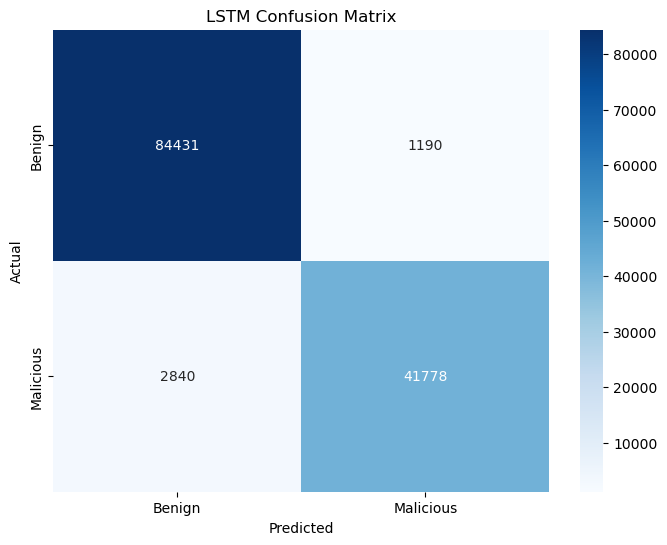

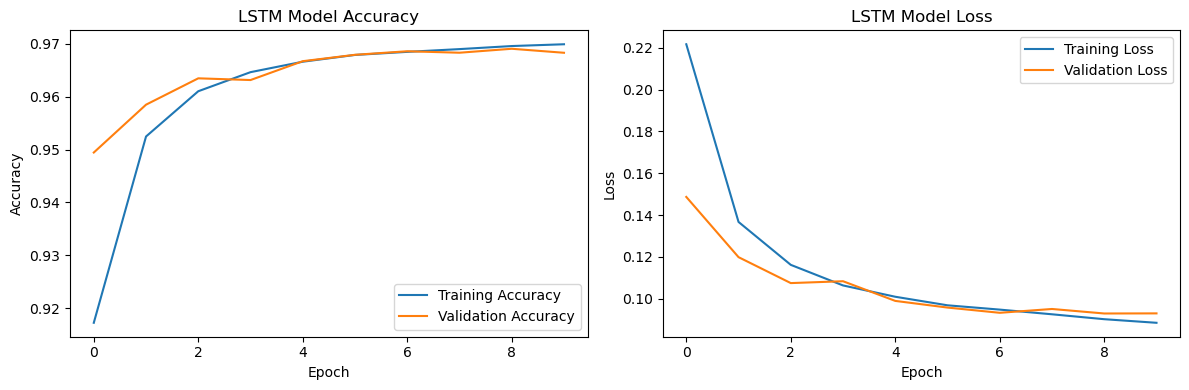

In [7]:
# buiild LSTM model
def build_lstm_model(input_shape):
    model = Sequential([
        LSTM(128, input_shape=input_shape, return_sequences=True),
        LSTM(128, return_sequences=True),
        LSTM(256),
        Dropout(0.3),
        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

#INIT LSTM
lstm_model = build_lstm_model((X_train_lstm.shape[1], 1))
history = lstm_model.fit(X_train_lstm, y_train, epochs=10, batch_size=128, validation_split=0.2, verbose=1)

#Save MODEL
lstm_model.save('LSTM_enhanced.h5')

y_pred_lstm = (lstm_model.predict(X_test_lstm) > 0.5).astype(int)

print("\nLSTM Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lstm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lstm):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lstm):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_lstm):.4f}")

# cm
cm_lstm = confusion_matrix(y_test, y_pred_lstm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lstm, annot=True, fmt='d', cmap='Blues', xticklabels=['Benign', 'Malicious'], yticklabels=['Benign', 'Malicious'])
plt.title('LSTM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('lstm_confusion_matrix.png')
plt.show()

#PLOT HISTORY
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('lstm_training_history.png')
plt.show()

In [ ]:
# Compare model performance
metrics = {
    'Model': ['Logistic Regression', 'LSTM'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_lstm)],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_lstm)],
    'Recall': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_lstm)],
    'F1-Score': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_lstm)]
}

metrics_df = pd.DataFrame(metrics)
print("\nModel Comparison:")
print(metrics_df)

# Plot comparison
metrics_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(kind='bar', figsize=(10, 6))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.savefig('model_comparison.png')
plt.show()

# LSTM & TF-IDF


**Feature Extraction TF-IDF**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Features and labels
X = df['url']
y = df['type']

vectorizer = TfidfVectorizer(max_features=10000, analyzer='char', ngram_range=(3, 5))
X_tfidf = vectorizer.fit_transform(X)
print("TF-IDF shape:", X_tfidf.shape)

X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


TF-IDF shape: (651191, 10000)
Train size: (520952, 10000)
Test size: (130239, 10000)


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from sklearn.metrics import classification_report, confusion_matrix

In [ ]:
# ENCODE labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['type'])

In [ ]:
#LOWER URLS'normalization'
urls = df['url'].astype(str).str.lower().values
labels = df['label'].values

tokenizer = Tokenizer(char_level=True)
tokenizer.fit_on_texts(urls)

In [ ]:
# Convert to sequences
sequences = tokenizer.texts_to_sequences(urls)

# Pad sequences to same length
max_len = 100  
X = pad_sequences(sequences, maxlen=max_len, padding='post')
y = to_categorical(labels)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=labels, random_state=42)

# dimensions
vocab_size = len(tokenizer.word_index) + 1
num_classes = y.shape[1]

**LSTM**

In [ ]:
# INIT LSTM model
model = Sequential([
    Embedding(input_dim=vocab_size, output_dim=128, input_length=max_len),
    LSTM(128, return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# COMPLIE
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train
#Save the training history
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=64  
)

Epoch 1/10
7326/7326 ━━━━━━━━━━━━━━━━━━━━ 96s 13ms/step - accuracy: 0.9768 - loss: 0.0748 - val_accuracy: 0.9768 - val_loss: 0.0740
Epoch 2/10
7326/7326 ━━━━━━━━━━━━━━━━━━━━ 142s 13ms/step - accuracy: 0.9792 - loss: 0.0673 - val_accuracy: 0.9777 - val_loss: 0.0726
Epoch 3/10
7326/7326 ━━━━━━━━━━━━━━━━━━━━ 144s 13ms/step - accuracy: 0.9802 - loss: 0.0634 - val_accuracy: 0.9770 - val_loss: 0.0731
Epoch 4/10
7326/7326 ━━━━━━━━━━━━━━━━━━━━ 142s 13ms/step - accuracy: 0.9812 - loss: 0.0603 - val_accuracy: 0.9765 - val_loss: 0.0755
Epoch 5/10
7326/7326 ━━━━━━━━━━━━━━━━━━━━ 143s 13ms/step - accuracy: 0.9818 - loss: 0.0578 - val_accuracy: 0.9781 - val_loss: 0.0716
Epoch 6/10
7326/7326 ━━━━━━━━━━━━━━━━━━━━ 142s 13ms/step - accuracy: 0.9830 - loss: 0.0544 - val_accuracy: 0.9787 - val_loss: 0.0678
Epoch 7/10
7326/7326 ━━━━━━━━━━━━━━━━━━━━ 95s 13ms/step - accuracy: 0.9833 - loss: 0.0530 - val_accuracy: 0.9794 - val_loss: 0.0667
Epoch 8/10
7326/7326 ━━━━━━━━━━━━━━━━━━━━ 143s 13ms/step - accuracy: 0.

**Model Evaluation**

In [ ]:
#EVALUATION
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# CLASSIFICATION Report
print("\nLSTM Classification Report:")
print(classification_report(y_true, y_pred, target_names=le.classes_))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred))


4070/4070 ━━━━━━━━━━━━━━━━━━━━ 17s 4ms/step

LSTM Classification Report:
              precision    recall  f1-score   support

      benign       0.98      0.99      0.99     85621
  defacement       0.99      1.00      0.99     19292
     malware       0.99      0.95      0.97      6504
    phishing       0.96      0.91      0.93     18822

    accuracy                           0.98    130239
   macro avg       0.98      0.96      0.97    130239
weighted avg       0.98      0.98      0.98    130239


Confusion Matrix:
[[85001    88    16   516]
 [   28 19244     2    18]
 [   59    47  6149   249]
 [ 1504   156    18 17144]]


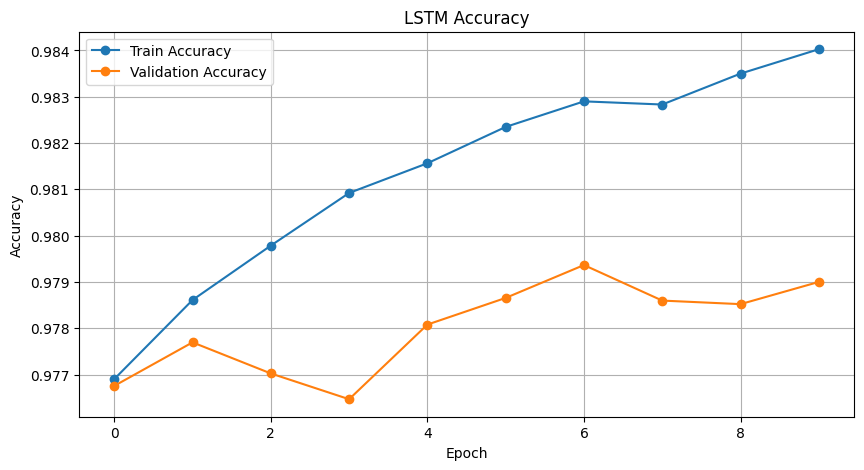

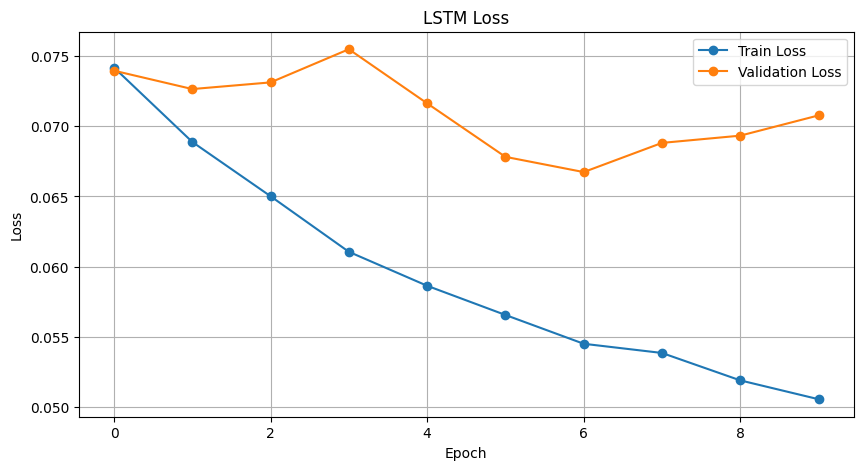

In [ ]:
import matplotlib.pyplot as plt



# PLOT Accuracy
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('LSTM Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# PLOT Loss
plt.figure(figsize=(10, 5))
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('LSTM Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


**save model for the app**

In [ ]:
model.save('LSTM.h5')

In [ ]:
import re
from urllib.parse import urlparse
from tld import get_tld
from googlesearch import search

def having_ip_address(url):
    match = re.search(
        r'(([01]?\d\d?|2[0-4]\d|25[0-5])\.){3}([01]?\d\d?|2[0-4]\d|25[0-5])|'
        r'((0x[0-9a-fA-F]{1,2})\.){3}(0x[0-9a-fA-F]{1,2})|'
        r'(?:[a-fA-F0-9]{1,4}:){7}[a-fA-F0-9]{1,4}', url)
    return 1 if match else 0

def abnormal_url(url):
    hostname = str(urlparse(url).hostname)
    return 1 if hostname and hostname in url else 0

def google_index(url):
    try:
        site = search(url, num_results=5)
        return 1 if site else 0
    except:
        return 0

def count_dot(url): return url.count('.')
def count_www(url): return url.count('www')
def count_atrate(url): return url.count('@')
def no_of_dir(url): return urlparse(url).path.count('/')
def no_of_embed(url): return urlparse(url).path.count('//')

def suspicious_words(url):
    return 1 if re.search(r'paypal|login|signin|bank|account|update|free|lucky|service|bonus|ebayisapi|webscr', url, re.IGNORECASE) else 0

def shortening_service(url):
    return 1 if re.search(
        r'bit\.ly|goo\.gl|shorte\.st|go2l\.ink|x\.co|ow\.ly|t\.co|tinyurl|tr\.im|is\.gd|cli\.gs|'
        r'yfrog\.com|migre\.me|ff\.im|tiny\.cc|url4\.eu|twit\.ac|su\.pr|twurl\.nl|snipurl\.com|'
        r'short\.to|BudURL\.com|ping\.fm|post\.ly|Just\.as|bkite\.com|snipr\.com|fic\.kr|loopt\.us|'
        r'doiop\.com|short\.ie|kl\.am|wp\.me|rubyurl\.com|om\.ly|to\.ly|bit\.do|t\.co|lnkd\.in|'
        r'db\.tt|qr\.ae|adf\.ly|bitly\.com|cur\.lv|tinyurl\.com|ity\.im|q\.gs|po\.st|bc\.vc|'
        r'twitthis\.com|u\.to|j\.mp|buzurl\.com|cutt\.us|u\.bb|yourls\.org|x\.co|prettylinkpro\.com|'
        r'scrnch\.me|filoops\.info|vzturl\.com|qr\.net|1url\.com|tweez\.me|v\.gd|link\.zip\.net',
        url) else 0

def count_https(url): return url.count('https')
def count_http(url): return url.count('http')
def count_per(url): return url.count('%')
def count_ques(url): return url.count('?')
def count_hyphen(url): return url.count('-')
def count_equal(url): return url.count('=')
def url_length(url): return len(str(url))
def hostname_length(url): return len(urlparse(url).netloc)

def fd_length(url):
    try:
        return len(urlparse(url).path.split('/')[1])
    except:
        return 0

def tld_length(tld):
    try:
        return len(tld)
    except:
        return -1

def digit_count(url): return sum(c.isdigit() for c in url)
def letter_count(url): return sum(c.isalpha() for c in url)

# Full feature extractor for a single URL
def extract_features(url, include_google_index=False):
    features = [
        having_ip_address(url),
        abnormal_url(url),
        count_dot(url),
        count_www(url),
        count_atrate(url),
        no_of_dir(url),
        no_of_embed(url),
        shortening_service(url),
        count_per(url),
        count_ques(url),
        count_hyphen(url),
        count_equal(url),
        url_length(url),
        count_https(url),
        count_http(url),
        hostname_length(url),
        suspicious_words(url),
        fd_length(url),
        tld_length(get_tld(url, fail_silently=True)),
        digit_count(url),
        letter_count(url)
    ]
    if include_google_index:
        features.insert(2, google_index(url))  # Insert after abnormal_url
    return features


In [ ]:
import gradio as gr
import re
from urllib.parse import urlparse
from tld import get_tld
from googlesearch import search
import numpy as np
import tensorflow as tf

# Load your trained model
model = tf.keras.models.load_model("LSTM.h5")
# Feature extraction wrapper
def extract_features(url):
    features = [
        having_ip_address(url),
        abnormal_url(url),
        count_dot(url),
        count_www(url),
        count_atrate(url),
        no_of_dir(url),
        no_of_embed(url),
        shortening_service(url),
        count_per(url),
        count_ques(url),
        count_hyphen(url),
        count_equal(url),
        url_length(url),
        count_https(url),
        count_http(url),
        hostname_length(url),
        suspicious_words(url),
        fd_length(url),
        tld_length(get_tld(url, fail_silently=True)),
        digit_count(url),
        letter_count(url)
    ]
    return np.array([features])

# Prediction function
def predict_url(url):
    features = extract_features(url)
    pred = model.predict(features)[0][0]  # binary classification with sigmoid
    label = "Bengin" if pred > 0.85 else "Malicious"
    return f"Prediction: {label} )"


iface = gr.Interface(
    fn=predict_url,
    inputs=gr.Textbox(label="Enter URL"),
    outputs=gr.Textbox(label="Prediction"),
    title="Malicious URL Detector",
    description="Paste a URL to check if it's potentially malicious based on URL features."
)

iface.launch()
